# COMP47950 Quantum Machine Learning Project

Replication of Selig et al. [20] variational classifier on 2–3 datasets, with classical baseline and real-device inference.

## 1. Datasets and train/test split

We use three datasets from [20] Table 1, loaded via scikit-learn:

| Dataset | Features | Classes | Train | Test | Notes |
|---------|----------|---------|-------|------|-------|
| Iris | 4 | 3 | 90 | 60 | No PCA |
| Wine | 13 | 3 | 108 | 70 | PCA (8 or 12 PCs) in preprocessing |
| Breast Cancer Wisconsin | 32 | 2 | 449 | 120 | PCA (12 or 16 PCs) in preprocessing |

**Split strategy:** Stratified train/test split matching [20] sizes, with `random_state=42` for reproducibility. Data is loaded on-the-fly from sklearn (no local caching).

In [29]:
from qml_project.datasets import (
    load_iris_splits,
    load_wine_splits,
    load_breast_cancer_splits,
)

In [30]:
X_iris_tr, X_iris_te, y_iris_tr, y_iris_te = load_iris_splits()
X_wine_tr, X_wine_te, y_wine_tr, y_wine_te = load_wine_splits()
X_bc_tr, X_bc_te, y_bc_tr, y_bc_te = load_breast_cancer_splits()

print("Iris:", X_iris_tr.shape, X_iris_te.shape)
print("Wine:", X_wine_tr.shape, X_wine_te.shape)
print("Breast Cancer:", X_bc_tr.shape, X_bc_te.shape)

Iris: (90, 4) (60, 4)
Wine: (108, 13) (70, 13)
Breast Cancer: (449, 30) (120, 30)


In [31]:
import numpy as np

for name, y_tr, y_te in [
    ("Iris", y_iris_tr, y_iris_te),
    ("Wine", y_wine_tr, y_wine_te),
    ("Breast Cancer", y_bc_tr, y_bc_te),
]:
    tr_counts = np.bincount(y_tr)
    te_counts = np.bincount(y_te)
    print(f"{name}: train {dict(zip(range(len(tr_counts)), tr_counts))}, test {dict(zip(range(len(te_counts)), te_counts))}")

Iris: train {0: np.int64(30), 1: np.int64(30), 2: np.int64(30)}, test {0: np.int64(20), 1: np.int64(20), 2: np.int64(20)}
Wine: train {0: np.int64(36), 1: np.int64(43), 2: np.int64(29)}, test {0: np.int64(23), 1: np.int64(28), 2: np.int64(19)}
Breast Cancer: train {0: np.int64(167), 1: np.int64(282)}, test {0: np.int64(45), 1: np.int64(75)}


## 2. Preprocessing

Centre and scale (StandardScaler), optional PCA for Wine/BC, and [20] angle mapping for QML. Fit on train only; transform both splits.

**Angle mapping** ([20] Eq. 2): $f(x) = \frac{(1-\alpha^2)\pi}{q} \cdot W$ with α=0.1, q=3.

In [32]:
from qml_project.preprocessing import preprocess

# Iris: no PCA
X_iris_tr_cl, X_iris_te_cl, _ = preprocess(X_iris_tr, X_iris_te, apply_angle_mapping_flag=False)
X_iris_tr_qml, X_iris_te_qml, _ = preprocess(X_iris_tr, X_iris_te, apply_angle_mapping_flag=True)

# Wine: PCA 8 components
X_wine_tr_cl, X_wine_te_cl, _ = preprocess(X_wine_tr, X_wine_te, n_components=8, apply_angle_mapping_flag=False)
X_wine_tr_qml, X_wine_te_qml, _ = preprocess(X_wine_tr, X_wine_te, n_components=8, apply_angle_mapping_flag=True)

# Breast Cancer: PCA 12 components
X_bc_tr_cl, X_bc_te_cl, _ = preprocess(X_bc_tr, X_bc_te, n_components=12, apply_angle_mapping_flag=False)
X_bc_tr_qml, X_bc_te_qml, _ = preprocess(X_bc_tr, X_bc_te, n_components=12, apply_angle_mapping_flag=True)

print("Classical (scale+PCA): Iris", X_iris_tr_cl.shape, "Wine", X_wine_tr_cl.shape, "BC", X_bc_tr_cl.shape)

Classical (scale+PCA): Iris (90, 4) Wine (108, 8) BC (449, 12)


## 3. Classical ML baseline

We train three classical classifiers (Logistic Regression, Random Forest, SVM) on the preprocessed data (scale + PCA where applicable). **Data prep:** Same as above; no angle mapping. **Sampling:** Fixed train/test split from §1. **Metrics:** Accuracy, F1 (macro), precision (macro), recall (macro), and confusion matrix.

In [33]:
from qml_project.baselines import evaluate_baselines
import pandas as pd

results_iris = evaluate_baselines(X_iris_tr_cl, X_iris_te_cl, y_iris_tr, y_iris_te)
results_wine = evaluate_baselines(X_wine_tr_cl, X_wine_te_cl, y_wine_tr, y_wine_te)
results_bc = evaluate_baselines(X_bc_tr_cl, X_bc_te_cl, y_bc_tr, y_bc_te)

In [34]:
def metrics_table(results: dict, dataset: str) -> pd.DataFrame:
    rows = []
    for model, r in results.items():
        rows.append({
            "Model": model,
            "Dataset": dataset,
            "Accuracy": f"{r['accuracy']:.4f}",
            "F1 (macro)": f"{r['f1_macro']:.4f}",
            "Precision (macro)": f"{r['precision_macro']:.4f}",
            "Recall (macro)": f"{r['recall_macro']:.4f}",
        })
    return pd.DataFrame(rows)

pd.concat([
    metrics_table(results_iris, "Iris"),
    metrics_table(results_wine, "Wine"),
    metrics_table(results_bc, "Breast Cancer"),
], ignore_index=True)

,Model,Dataset,Accuracy,F1 (macro),Precision (macro),Recall (macro)
0,Logistic Regression,Iris,0.9333,0.9332,0.9360,0.9333
1,Random Forest,Iris,0.9167,0.9162,0.9224,0.9167
2,SVM,Iris,0.9500,0.9500,0.9507,0.9500
3,Logistic Regression,Wine,0.9571,0.9589,0.9610,0.9586
4,Random Forest,Wine,0.9000,0.9045,0.9062,0.9033
5,SVM,Wine,0.9857,0.9851,0.9885,0.9825
6,Logistic Regression,Breast Cancer,0.9667,0.9730,0.9863,0.9600
7,Random Forest,Breast Cancer,0.9333,0.9467,0.9467,0.9467
8,SVM,Breast Cancer,0.9750,0.9799,0.9865,0.9733


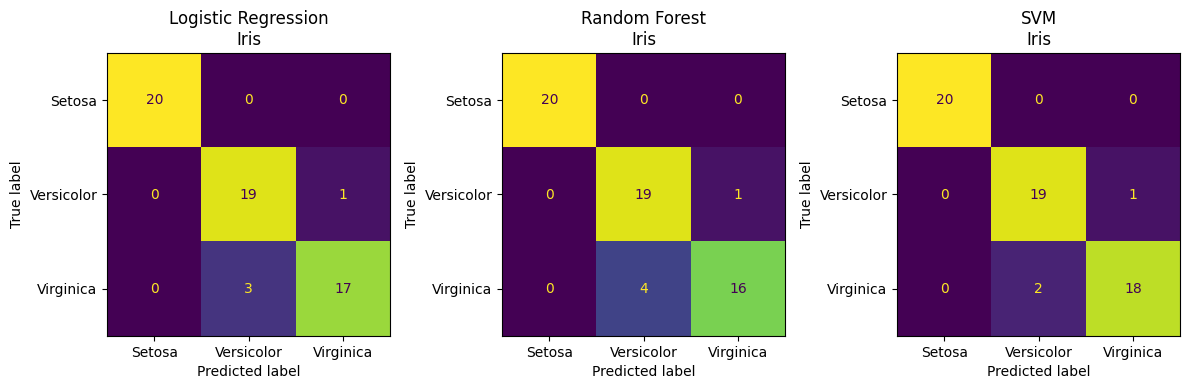

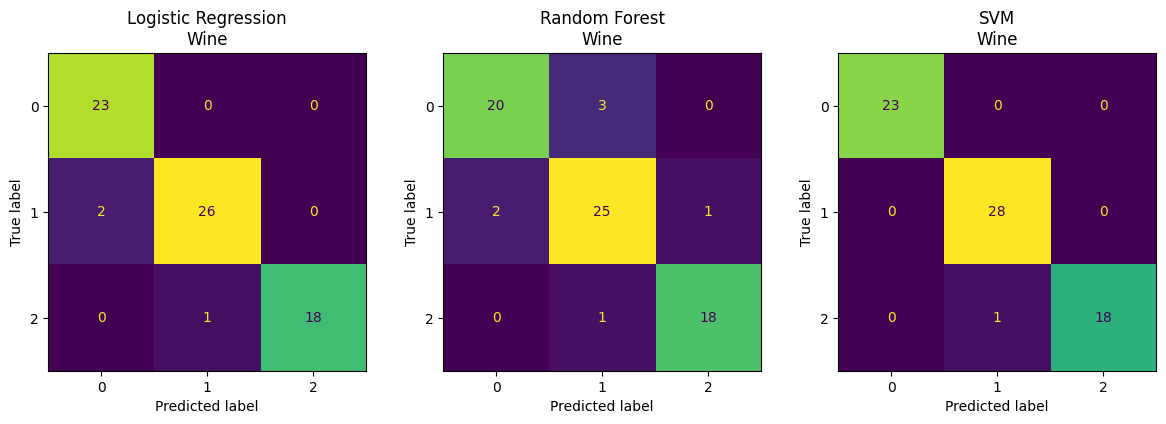

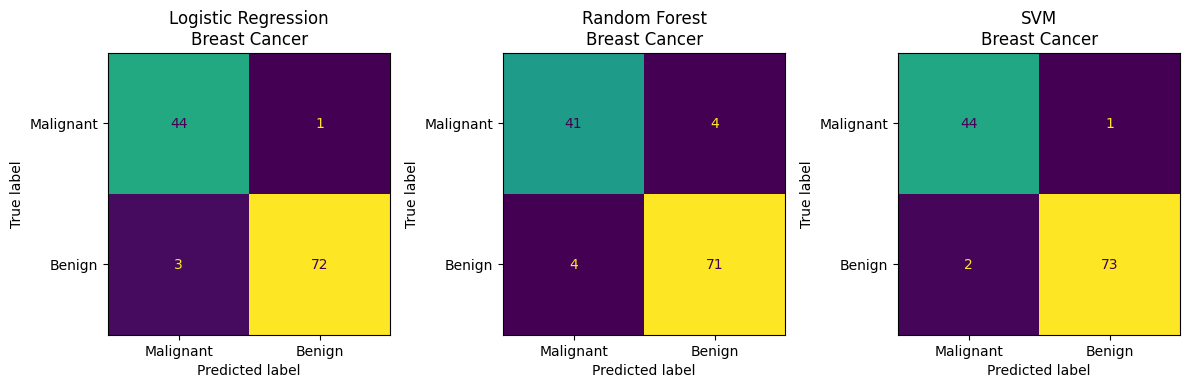

In [35]:
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay

def plot_confusion_matrices(results: dict, dataset: str, class_names: list[str] | None = None):
    fig, axes = plt.subplots(1, 3, figsize=(12, 4))
    for ax, (model, r) in zip(axes, results.items()):
        disp = ConfusionMatrixDisplay(
            confusion_matrix=r["confusion_matrix"],
            display_labels=class_names or [str(i) for i in range(r["n_classes"])],
        )
        disp.plot(ax=ax, colorbar=False)
        ax.set_title(f"{model}\n{dataset}")
    plt.tight_layout()
    plt.show()

plot_confusion_matrices(results_iris, "Iris", ["Setosa", "Versicolor", "Virginica"])
plot_confusion_matrices(results_wine, "Wine")
plot_confusion_matrices(results_bc, "Breast Cancer", ["Malignant", "Benign"])

### QML-challenge commentary

**Iris:** 4 features, 3 classes, relatively well-separated. QML will be challenged by limited expressivity with few qubits (≤4); the variational circuit may underfit compared with classical models.

**Wine:** 8 PCs (after PCA), 3 classes, some overlap between classes. QML is challenged by encoding 8 features into angles; shallow circuits may not capture class boundaries as well as classical models.

**Breast Cancer:** 12 PCs, 2 classes, moderate class imbalance. QML is challenged by circuit depth vs noise: deeper circuits could model boundaries better but are more sensitive to NISQ-era noise [20].